# Exp-02 Edge Detection, Line Detection, Corner Detection

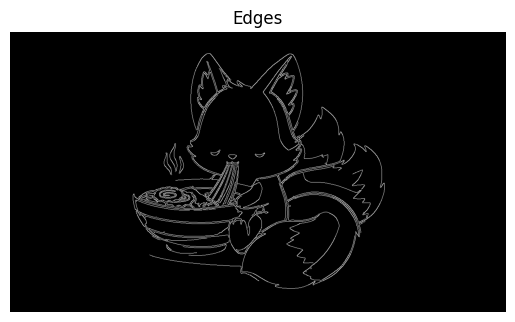

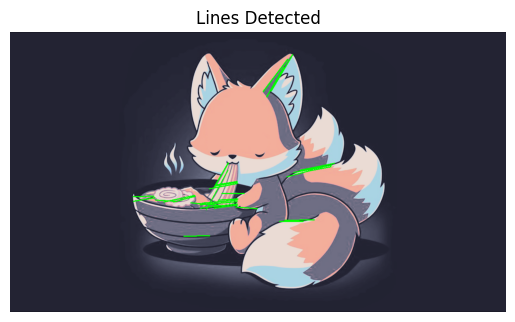

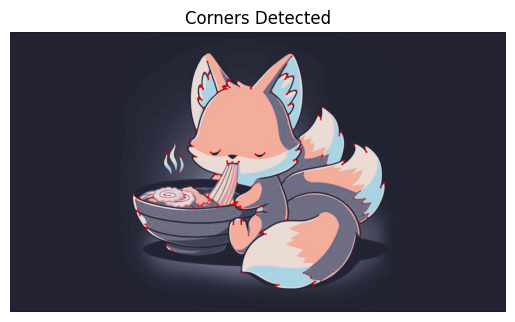

In [1]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('fox.png')

# Check image
if img is None:
    print("Error loading image")
    exit()

# Convert to grayscale (needed for most operations)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ---------------------------
# 1. EDGE DETECTION (Canny)
# ---------------------------
edges = cv2.Canny(gray, 100, 200)  # (low_threshold, high_threshold)

plt.imshow(edges, cmap='gray')
plt.title("Edges")
plt.axis('off')
plt.show()

# ---------------------------
# 2. LINE DETECTION (Hough Transform)
# ---------------------------
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=100,
                        minLineLength=50, maxLineGap=10)

# Draw detected lines on image
line_img = img.copy()

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 2)

line_img_rgb = cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB)

plt.imshow(line_img_rgb)
plt.title("Lines Detected")
plt.axis('off')
plt.show()

# ---------------------------
# 3. CORNER DETECTION (Harris)
# ---------------------------
gray_float = np.float32(gray)

corners = cv2.cornerHarris(gray_float, 2, 3, 0.04)

# Dilate to mark corners clearly
corners = cv2.dilate(corners, None)

corner_img = img.copy()

# Mark corners in red
corner_img[corners > 0.01 * corners.max()] = [0, 0, 255]

corner_img_rgb = cv2.cvtColor(corner_img, cv2.COLOR_BGR2RGB)

plt.imshow(corner_img_rgb)
plt.title("Corners Detected")
plt.axis('off')
plt.show()